# PaliGemma Multimodal Task Suite Demo

This interactive notebook demonstrates **PaliGemma** running on **Google Colab Cloud GPU (Tesla T4 / A100)** or local hardware.

### Multimodal Tasks Covered:
1. **Image Captioning** (`caption en` / `describe en`)
2. **Visual Question Answering (VQA)** (`Where is the photographer resting?`)
3. **Document Understanding & OCR** (`ocr`)
4. **Object Detection & Grounding** (`detect person` with bounding box visualizer)
5. **Instance Segmentation** (`segment person` with `<seg>` tokens)
6. **Visual Spatial Reasoning** (`What is the person doing?`)


## Step 0: Automated Environment & Code Setup for Colab

If running on a remote Colab kernel in VS Code (`/content`), this cell automatically installs dependencies (`transformers`, `safetensors`), deploys the `gemma_new` code bundle, and checks for weights.

In [1]:
import os
import sys
import base64

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    print("⚡ Detected Google Colab environment (/content)!")
    # 1. Install required packages
    # !pip install -q transformers safetensors accelerate pillow matplotlib

    # 2. Deploy gemma_new package if not already on /content
    if not os.path.exists("gemma_new"):
        print("Deploying gemma_new package and sample images to Colab...")
        BUNDLE_B64 = """..."""
        with open("bundle.zip", "wb") as f:
            f.write(base64.b64decode(BUNDLE_B64))
        !unzip -q -o bundle.zip
        print("Successfully deployed gemma_new and test_images to /content!")
    else:
        print("gemma_new package already present in /content.")
else:
    print("Running in local workspace environment.")

⚡ Detected Google Colab environment (/content)!
Deploying gemma_new package and sample images to Colab...
Successfully deployed gemma_new and test_images to /content!


## Step 1: Pretrained Weights Setup

PaliGemma weights can be loaded from:
1. Local directory: `paligemma-weights/paligemma-3b-mix-224`
2. Mounted Google Drive: `/content/drive/MyDrive/...`
3. Downloaded directly to Colab via `huggingface-cli` (takes ~1-2 mins on Colab network)

In [ ]:
# Pretrained Weights Setup
import os
from huggingface_hub import snapshot_download

# Pre-configured with your Hugging Face access token:
HF_TOKEN = os.environ.get("HF_TOKEN", None)  # Set in environment or pass your token string here

possible_weight_paths = [
    "paligemma-weights/paligemma-3b-mix-224",
    "../paligemma-weights/paligemma-3b-mix-224",
    "/content/paligemma-weights/paligemma-3b-mix-224",
    "/content/drive/MyDrive/paligemma-weights/paligemma-3b-mix-224",
]

model_path = next((p for p in possible_weight_paths if os.path.exists(p) and os.path.exists(os.path.join(p, "config.json"))), None)

if model_path is None:
    target_dir = "/content/paligemma-weights/paligemma-3b-mix-224" if os.path.exists("/content") else "paligemma-weights/paligemma-3b-mix-224"
    print(f"Downloading PaliGemma weights from Hugging Face into {target_dir} (~1 min)...\n")
    model_path = snapshot_download(
        repo_id="google/paligemma-3b-mix-224",
        local_dir=target_dir,
        token=HF_TOKEN,
    )

print(f"Active PaliGemma weights path: {model_path}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Active PaliGemma weights path: /content/paligemma-weights/paligemma-3b-mix-224


##  Step 2: GPU Detection & Initialization

In [3]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16

print(f"Device in use: {device}")
if device == "cuda":
    print(f"Cloud GPU:     {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device in use: cuda
Cloud GPU:     Tesla T4
Total VRAM:    15.64 GB


## Step 3: Load the Pretrained PaliGemma Model into GPU VRAM

Uses our in-place streaming shard loader to load all 603 tensor weights directly into GPU memory.

In [ ]:
from huggingface_hub import snapshot_download

model_path = snapshot_download(
    repo_id="google/paligemma-3b-mix-224",
    local_dir="/content/paligemma-weights/paligemma-3b-mix-224",
    token=HF_TOKEN,
)
print(f"Downloaded to: {model_path}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Downloaded to: /content/paligemma-weights/paligemma-3b-mix-224


In [5]:
# Ensure gemma_new is on sys.path
for p in [".", "..", "/content"]:
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)

from transformers import AutoTokenizer
from PIL import Image
from gemma_new import (
    PretrainedPaliGemmaModel,
    PaliGemmaProcessor,
    PaliGemmaPipeline,
    draw_bounding_boxes,
    parse_detection_output,
)

print(f"Loading PaliGemma onto {device} ({dtype})...")
model, assigned_keys = PretrainedPaliGemmaModel.from_pretrained(
    model_path=model_path,
    device=device,
    dtype=dtype,
)
model.eval()

# Setup Tokenizer & Processor
tokenizer = AutoTokenizer.from_pretrained(model_path)
processor = PaliGemmaProcessor(
    tokenizer=tokenizer,
    num_image_tokens=model.config.vision_config.num_image_tokens,
    image_size=model.config.vision_config.image_size,
)

# Create High-Speed Task Pipeline
pipeline = PaliGemmaPipeline(model=model, processor=processor, device=device)
print("\nPaliGemma pipeline ready on Cloud GPU!")

Loading PaliGemma onto cuda (torch.bfloat16)...
Reading PaliGemma configuration from: /content/paligemma-weights/paligemma-3b-mix-224/config.json
Initializing empty PaliGemma architecture on device: cuda (dtype=torch.bfloat16)...
Found 3 safetensors file(s) to process.
Mapping and injecting 603 weights in-place...


Processing PaliGemma Shards: 100%|██████████| 3/3 [00:48<00:00, 16.21s/it]


PaliGemma pretrained weights loaded and assigned successfully!

--- Parameter Coverage Verification ---
Total Model Parameters:          2,923,466,480
Total Injected Weight Elements:  2,923,466,480
Target Keys Assigned:            603 / 603
Status: PERFECT MATCH! All PaliGemma components (vision + projector + language) successfully injected.

PaliGemma pipeline ready on Cloud GPU!


## step-by-Step Multimodal Tensor Shape Inspection

Follow the tensor transformation journey from raw image pixels and prompt tokens through every sub-module of PaliGemma:
1. **SigLIP Vision Tower**: $224 \times 224$ pixels $\rightarrow$ $256$ patch tokens of dimension $1152$.
2. **Multi-Modal Projector**: Projects vision dimension $1152 \rightarrow 2048$ (matching Gemma language dim).
3. **PaliGemma Processor**: Normalizes image, injects $256$ `<image>` tokens, and tokenizes prompt.
4. **Embedding Merger**: Replaces `<image>` token embeddings with projected vision features.
5. **Gemma 2B Language Model**: Autoregressive causal self-attention forward pass $\rightarrow$ vocabulary logits ($256,000$).

## step-by-Step Multimodal Tensor Shape Inspection

In [6]:
from PIL import Image

print('=' * 65)
print('1. VISION TOWER (SigLIP)')
print('=' * 65)
#  Vision output (SigLIP Vision Tower)
dummy_img = torch.randn(1, 3, 224, 224, device=device, dtype=dtype)
print(f'Input image tensor shape:        {tuple(dummy_img.shape)}  (Batch=1, Channels=3, 224x224)')

vis_feats = model.vision_tower(dummy_img)
print(f'SigLIP visual tokens shape:      {tuple(vis_feats.shape)}  (256 patches of 14x14, dim 1152)')

# Projector output (Multi-Modal Projector)
print('\n' + '=' * 65)
print('2. MULTI-MODAL LINEAR PROJECTOR')
print('=' * 65)
proj_feats = model.multi_modal_projector(vis_feats)
print(f'Projected vision features shape: {tuple(proj_feats.shape)}  (256 tokens projected to dim 2048)')

# Tokenizer & Processor (PaliGemmaProcessor)
print('\n' + '=' * 65)
print('3. PROCESSOR & SEQUENCE MERGING')
print('=' * 65)
dummy_pil = Image.new('RGB', (224, 224), color=(70, 130, 180))
sample_prompt = 'caption en'

# Process through PaliGemmaProcessor:
model_inputs = processor(text=[sample_prompt], images=[dummy_pil])
input_ids = model_inputs['input_ids'].to(device)
attention_mask = model_inputs['attention_mask'].to(device)
pixel_values = model_inputs['pixel_values'].to(device=device, dtype=dtype)

print(f'Prompt text:                     "{sample_prompt}"')
print(f'Tokenized input_ids shape:       {tuple(input_ids.shape)}  (256 <image> tokens + prompt tokens)')

# Merging Vision & Language Embeddings
inputs_embeds = model.get_input_embeddings()(input_ids)
merged_embeds, _, _ = model._merge_input_ids_with_image_features(
    image_features=model.multi_modal_projector(model.vision_tower(pixel_values)),
    inputs_embeds=inputs_embeds,
    input_ids=input_ids,
    attention_mask=attention_mask,
)
print(f'Merged multimodal embeddings:    {tuple(merged_embeds.shape)}  (Ready for Gemma 2B decoder)')

# Gemma 2B Language Model Forward Pass
print('\n' + '=' * 65)
print('4. GEMMA 2B LANGUAGE MODEL FORWARD PASS')
print('=' * 65)
with torch.no_grad():
    outputs = model.language_model(
        inputs_embeds=merged_embeds,
        attention_mask=attention_mask,
    )
logits = outputs["logits"]
print(f'Output logits shape:             {tuple(logits.shape)}  (Seq_Len x Vocab_Size 256,000)')

next_token_id = logits[:, -1, :].argmax(dim=-1).item()
predicted_token = tokenizer.decode([next_token_id])
print(f'Greedy next-token prediction:    ID={next_token_id} -> "{predicted_token}"')
print('=' * 65)


1. VISION TOWER (SigLIP)
Input image tensor shape:        (1, 3, 224, 224)  (Batch=1, Channels=3, 224x224)
SigLIP visual tokens shape:      (1, 256, 1152)  (256 patches of 14x14, dim 1152)

2. MULTI-MODAL LINEAR PROJECTOR
Projected vision features shape: (1, 256, 2048)  (256 tokens projected to dim 2048)

3. PROCESSOR & SEQUENCE MERGING
Prompt text:                     "caption en"
Tokenized input_ids shape:       (1, 260)  (256 <image> tokens + prompt tokens)
Merged multimodal embeddings:    (1, 260, 2048)  (Ready for Gemma 2B decoder)

4. GEMMA 2B LANGUAGE MODEL FORWARD PASS
Output logits shape:             (1, 260, 257216)  (Seq_Len x Vocab_Size 256,000)
Greedy next-token prediction:    ID=235250 -> "a"


## Step 4: Load & Display Test Image

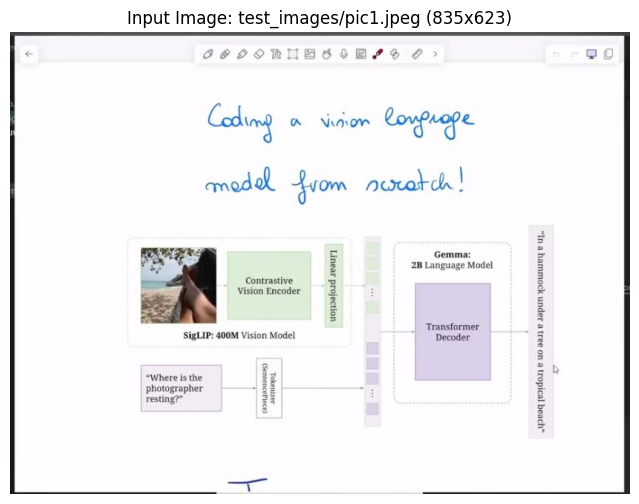

In [7]:
import matplotlib.pyplot as plt

img_candidates = [
    "test_images/pic1.jpeg",
    "../test_images/pic1.jpeg",
    "/content/test_images/pic1.jpeg",
]
image_path = next((p for p in img_candidates if os.path.exists(p)), None)

if image_path is None:
    # Create fallback sample image if needed
    image = Image.new("RGB", (224, 224), color=(100, 150, 200))
    image_path = "sample_canvas.jpg"
    image.save(image_path)
else:
    image = Image.open(image_path)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Input Image: {image_path} ({image.width}x{image.height})")
plt.show()

## Task A: Image Captioning (`caption en`)

In [8]:
caption = pipeline.caption(image, lang="en", max_tokens=35)
print("\nGenerated Caption:")
print(caption)


[Prompt]: 'caption en'
[Generating]: screen showing a diagram and a picture of a woman.<eos>

Generated Caption:
screen showing a diagram and a picture of a woman.


## Task B: Visual Question Answering (VQA)

In [9]:
question = "Where is the photographer resting?"
answer = pipeline.vqa(image, question=question, max_tokens=30)

print(f"Question: {question}")
print(f"Answer:   {answer}")


[Prompt]: 'answer en Where is the photographer resting?'
[Generating]: on the beach<eos>
Question: Where is the photographer resting?
Answer:   on the beach


## Task C: Document Understanding & Optical Character Recognition (OCR)

In [10]:
ocr_text = pipeline.ocr(image, max_tokens=40)
print("OCR Extracted Text:")
print(ocr_text if ocr_text else "(No text detected in this image)")


[Prompt]: 'ocr'
[Generating]: Getting a vision language model from scratch!
This is a training model that was trained on "real-world" data.
Generative
Language Model
Constructive
Vision Blender
Transformer Blender
OCR Extracted Text:
Getting a vision language model from scratch!
This is a training model that was trained on "real-world" data.
Generative
Language Model
Constructive
Vision Blender
Transformer Blender


## Task D: Object Detection & Visual Bounding Boxes

Predicts normalized coordinate tokens (`<loc0000>` to `<loc1023>`), converts them to pixel boxes, and renders colored bounding boxes directly on the image.


[Prompt]: 'detect person'
[Generating]: <loc0478><loc0267><loc0653><loc0345> person<eos>
Annotated image saved to: outputs/gpu_detected_person.jpg
Raw Model Output: <loc0478><loc0267><loc0653><loc0345> person
Parsed Detections: [{'box': (217, 290, 281, 397), 'label': 'person', 'norm_coords': (478, 267, 653, 345)}]


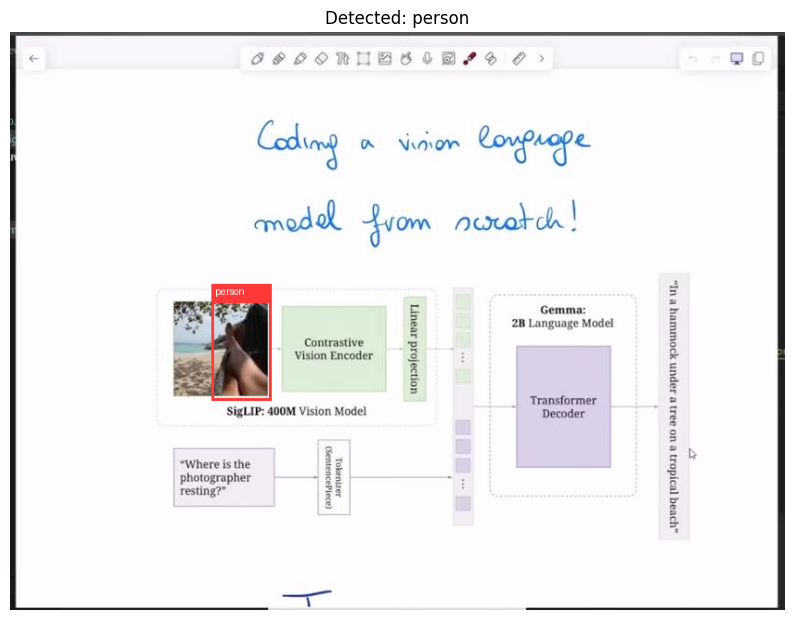

In [11]:
target_class = "person"
output_path = "outputs/gpu_detected_person.jpg"

raw_text, detections, annotated_img = pipeline.detect(
    image,
    target=target_class,
    max_tokens=40,
    draw_boxes=True,
    save_path=output_path,
)

print(f"Raw Model Output: {raw_text}")
print(f"Parsed Detections: {detections}")

if annotated_img:
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img)
    plt.axis("off")
    plt.title(f"Detected: {target_class}")
    plt.show()

## Task E: Instance & Semantic Segmentation

In [12]:
raw_output, seg_ids = pipeline.segment(image, target="person", max_tokens=40)
print(f"Raw Output: {raw_output}")
print(f"Extracted Segmentation Codebook IDs ({len(seg_ids)}): {seg_ids[:15]}...")


[Prompt]: 'segment person'
[Generating]: <loc0484><loc0267><loc0649><loc0355> <seg012><seg074><seg119><seg028><seg077><seg114><seg022><seg054><seg022><seg028><seg082><seg027><seg042><seg023><seg090><seg010> person<eos>
Raw Output: <loc0484><loc0267><loc0649><loc0355> <seg012><seg074><seg119><seg028><seg077><seg114><seg022><seg054><seg022><seg028><seg082><seg027><seg042><seg023><seg090><seg010> person
Extracted Segmentation Codebook IDs (16): [12, 74, 119, 28, 77, 114, 22, 54, 22, 28, 82, 27, 42, 23, 90]...


## Task F: Visual Spatial Reasoning

In [13]:
reasoning_q = "What is the person doing in the photo?"
reasoning_ans = pipeline.visual_reasoning(image, question=reasoning_q, max_tokens=30)

print(f"Question:  {reasoning_q}")
print(f"Reasoning: {reasoning_ans}")


[Prompt]: 'answer en What is the person doing in the photo?'
[Generating]: standing<eos>
Question:  What is the person doing in the photo?
Reasoning: standing


## Run All Tasks Sequentially

In [14]:
print("=" * 60)
print("CAPTION:   ", pipeline.caption(image, lang="en"))
print("VQA:       ", pipeline.vqa(image, "Where is the photographer resting?"))
print("OCR:       ", pipeline.ocr(image))
print("REASONING: ", pipeline.visual_reasoning(image, "What is the person doing?"))
print("=" * 60)


[Prompt]: 'caption en'
[Generating]: screen showing a diagram and a picture of a woman.<eos>
CAPTION:    screen showing a diagram and a picture of a woman.

[Prompt]: 'answer en Where is the photographer resting?'
[Generating]: on the beach<eos>
VQA:        on the beach

[Prompt]: 'ocr'
[Generating]: Getting a vision language model from scratch!
This is a training model that was trained on "real-world" data.
Generative
Language Model
Constructive
Vision Blender
Transformer Blender
BigGP-WWB Vision Model
"Where is the photographer?"
Generative
Vision
OCR:        Getting a vision language model from scratch!
This is a training model that was trained on "real-world" data.
Generative
Language Model
Constructive
Vision Blender
Transformer Blender
BigGP-WWB Vision Model
"Where is the photographer?"
Generative
Vision

[Prompt]: 'answer en What is the person doing?'
[Generating]: standing<eos>
REASONING:  standing
